<a href="https://colab.research.google.com/github/Msaid55/AC-Remote/blob/main/Copy_of_Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Tue Mar 24 17:40:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q diffusers transformers accelerate peft bitsandbytes safetensors sentencepiece
!git clone -q https://github.com/huggingface/diffusers
%cd diffusers
!pip install -q -e .
!pip install -q -r examples/dreambooth/requirements.txt

fatal: destination path 'diffusers' already exists and is not an empty directory.
/content/diffusers
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for diffusers (pyproject.toml) ... done


In [ ]:
instance_data_dir = "/content/drive/MyDrive/AI_Face_Project/My_Pic"
output_dir = "/content/drive/MyDrive/AI_Face_Project/output_lora"

instance_prompt = "photo of msaidperson"

import os
print("images:", len(os.listdir(instance_data_dir)))
os.makedirs(output_dir, exist_ok=True)

images: 13


In [ ]:
!accelerate config default

Configuration already exists at /root/.cache/huggingface/accelerate/default_config.yaml, will not override. Run `accelerate config` manually or pass a different `save_location`.


In [ ]:
%cd /content/diffusers/examples/dreambooth

!accelerate launch train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="/content/drive/MyDrive/AI_Face_Project/My_Pic" \
  --output_dir="/content/drive/MyDrive/AI_Face_Project/output_lora" \
  --instance_prompt="photo of msaidperson" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=800 \
  --mixed_precision="fp16" \
  --seed=42

/content/diffusers/examples/dreambooth
2026-03-24 17:42:16.804365: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774374136.825022   31953 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774374136.831911   31953 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774374136.849164   31953 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774374136.849190   31953 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774374136.849196   31953 computatio

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

pipe.load_lora_weights("/content/drive/MyDrive/AI_Face_Project/output_lora")

ImportError: peft>=0.17.0 is required for a normal functioning of this module, but found peft==0.7.0.

In [ ]:
!pip install -U peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 15.5 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.7.0
    Uninstalling peft-0.7.0:
      Successfully uninstalled peft-0.7.0


In [ ]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

pipe.load_lora_weights("/content/drive/MyDrive/AI_Face_Project/output_lora")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

OSError: Error no file named pytorch_lora_weights.bin found in directory /content/drive/MyDrive/AI_Face_Project/output_lora.

In [ ]:
import os

output_dir = "/content/drive/MyDrive/AI_Face_Project/output_lora"
print(os.listdir(output_dir))

[]


In [ ]:
%cd /content/diffusers/examples/dreambooth

!accelerate launch train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="/content/drive/MyDrive/AI_Face_Project/My_Pic" \
  --output_dir="/content/drive/MyDrive/AI_Face_Project/output_lora" \
  --instance_prompt="photo of msaidperson" \
  --resolution=512 \
  --train_batch_size=1 \
  --learning_rate=1e-4 \
  --max_train_steps=200 \
  --checkpointing_steps=100 \
  --mixed_precision="fp16"

/content/diffusers/examples/dreambooth
2026-03-24 17:54:12.905009: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774374852.945339   35259 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774374852.959277   35259 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774374853.026575   35259 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774374853.026622   35259 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774374853.026630   35259 computatio

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

pipe.load_lora_weights(
    "/content/drive/MyDrive/AI_Face_Project/output_lora",
    weight_name="pytorch_lora_weights.safetensors"
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


In [ ]:
%cd /content/diffusers/examples/dreambooth

!accelerate launch train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="/content/drive/MyDrive/AI_Face_Project/My_Pic" \
  --output_dir="/content/drive/MyDrive/AI_Face_Project/output_lora" \
  --instance_prompt="photo of msaidperson" \
  --resolution=512 \
  --train_batch_size=1 \
  --learning_rate=1e-4 \
  --max_train_steps=800 \
  --checkpointing_steps=200 \
  --mixed_precision="fp16"

/content/diffusers/examples/dreambooth
2026-03-24 18:27:35.732479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774376855.957919   44141 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774376856.022477   44141 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774376856.487076   44141 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774376856.487121   44141 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774376856.487126   44141 computatio

  0%|          | 0/40 [00:00<?, ?it/s]

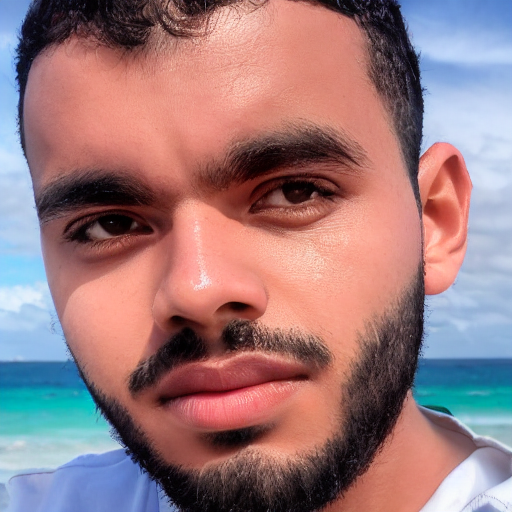

In [ ]:
prompt = "photo of msaidperson, same face, realistic, detailed facial features, natural skin, beach background, looking at camera"

negative_prompt = "different person, deformed face, ugly, bad anatomy, blurry, extra face, distorted, unrealistic"

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=40,
    guidance_scale=7.5
).images[0]

image